
# Unified E‑Commerce Revenue, Customer Journey & Product Intelligence Analytics

## Portfolio Grade Data Analytics Project

Datasets:
- customers.csv
- sessions.csv
- events.csv
- orders.csv
- order_items.csv
- products.csv
- reviews.csv

This notebook covers:
- Data Quality Assessment
- Data Cleaning
- Feature Engineering
- KPI Analysis
- Customer Analytics
- Product Analytics
- Marketing Analytics
- Funnel Analytics
- RFM Segmentation
- Pareto Analysis
- Review Analysis
- Business Recommendations


In [4]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import datetime

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')


## Load Data

In [5]:

customers = pd.read_csv('customers.csv')
sessions = pd.read_csv('sessions.csv')
events = pd.read_csv('events.csv')
orders = pd.read_csv('orders.csv')
order_items = pd.read_csv('order_items.csv')
products = pd.read_csv('products.csv')
reviews = pd.read_csv('reviews.csv')

datasets = {
    'customers': customers,
    'sessions': sessions,
    'events': events,
    'orders': orders,
    'order_items': order_items,
    'products': products,
    'reviews': reviews
}

for name, df in datasets.items():
    print(f'\n{name.upper()}')
    print(df.shape)
    print(df.head())



CUSTOMERS
(20000, 7)
   customer_id              name                       email country  age  \
0            1  Jennifer Salinas      nicholas59@example.org      JP   71   
1            2     Phillip Ramos  christinarubio@example.com      IN   26   
2            3       Dawn Fowler       jessica03@example.org      BR   21   
3            4      Mario Butler         paula27@example.org      FR   63   
4            5       Amber Brown         kevin85@example.net      BR   19   

  signup_date  marketing_opt_in  
0  2020-09-04              True  
1  2020-04-05             False  
2  2023-08-31              True  
3  2022-06-30              True  
4  2022-07-22              True  

SESSIONS
(120000, 6)
   session_id  customer_id           start_time   device   source country
0           1        12360  2021-12-27T00:01:36   mobile    email      DE
1           2        13917  2025-01-31T21:29:42  desktop  organic      PL
2           3         1022  2024-02-19T00:52:50   tablet  organic  

## Data Quality Assessment

In [6]:

quality_report = []

for name, df in datasets.items():
    quality_report.append({
        'dataset': name,
        'rows': df.shape[0],
        'columns': df.shape[1],
        'missing_values': int(df.isna().sum().sum()),
        'duplicates': int(df.duplicated().sum())
    })

quality_df = pd.DataFrame(quality_report)
quality_df


,dataset,rows,columns,missing_values,duplicates
0,customers,20000,7,0,0
1,sessions,120000,6,0,0
2,events,760958,10,3594504,0
3,orders,33580,10,0,0
4,order_items,59163,5,0,73
5,products,1197,6,0,0
6,reviews,10780,6,0,0


## Data Cleaning & Type Conversion

In [7]:

customers['signup_date'] = pd.to_datetime(customers['signup_date'])
sessions['start_time'] = pd.to_datetime(sessions['start_time'])
events['timestamp'] = pd.to_datetime(events['timestamp'])
orders['order_time'] = pd.to_datetime(orders['order_time'])
reviews['review_time'] = pd.to_datetime(reviews['review_time'])

for df in datasets.values():
    df.drop_duplicates(inplace=True)


## Feature Engineering

In [37]:

orders['year'] = orders['order_time'].dt.year
orders['month'] = orders['order_time'].dt.month_name()
orders['quarter'] = orders['order_time'].dt.quarter

orders['aov'] = orders['total_usd']

customers['signup_year'] = customers['signup_date'].dt.year

order_items_ext = order_items.merge(
    products[['product_id', 'category', 'margin_usd']],
    on='product_id',
    how='left'
)
order_items_ext['margin_total'] = order_items_ext['quantity'] * order_items_ext['margin_usd']

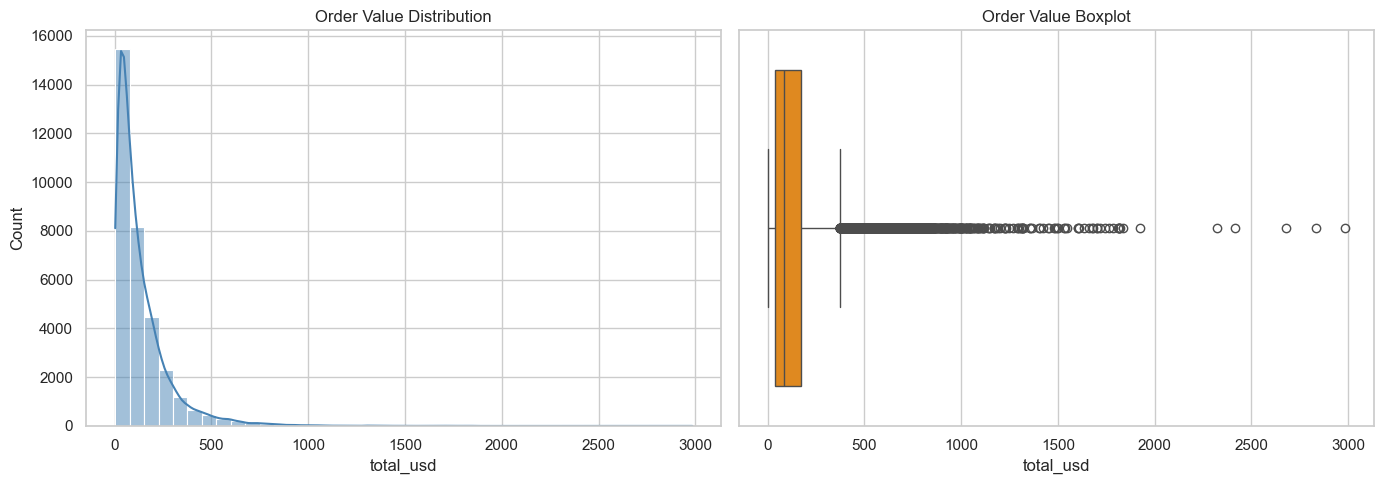

In [41]:

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(orders['total_usd'], bins=40, kde=True, ax=axes[0], color='steelblue')
axes[0].set_title('Order Value Distribution')
axes[0].set_xlabel('total_usd')

sns.boxplot(x=orders['total_usd'], ax=axes[1], color='darkorange')
axes[1].set_title('Order Value Boxplot')
axes[1].set_xlabel('total_usd')

plt.tight_layout()
plt.show()
     



## KPI Framework

In [36]:
kpis = {
    'Total Revenue (USD)': orders['total_usd'].sum(),
    'Total Orders': orders['order_id'].nunique(),
    'Unique Purchasing Customers': orders['customer_id'].nunique(),
    'Average Order Value (USD)': orders['total_usd'].mean(),
    'Repeat Purchase Rate': (orders['customer_id'].value_counts().gt(1).sum() / orders['customer_id'].nunique()),
    'Average Items per Order': order_items.groupby('order_id')['quantity'].sum().mean(),
    'Average Discount %': orders['discount_pct'].mean(),
    'Average Rating': reviews['rating'].mean(),
}

kpi_df = pd.DataFrame({'KPI': list(kpis.keys()), 'Current Value': list(kpis.values())})
kpi_df

,KPI,Current Value
0,Total Revenue (USD),4.493217e+06
1,Total Orders,3.358000e+04
2,Unique Purchasing Customers,1.626800e+04
3,Average Order Value (USD),1.338064e+02
4,Repeat Purchase Rate,6.174699e-01
5,Average Items per Order,2.293955e+00
6,Average Discount %,7.160214e+00
7,Average Rating,3.934323e+00


## Revenue Trend Analysis

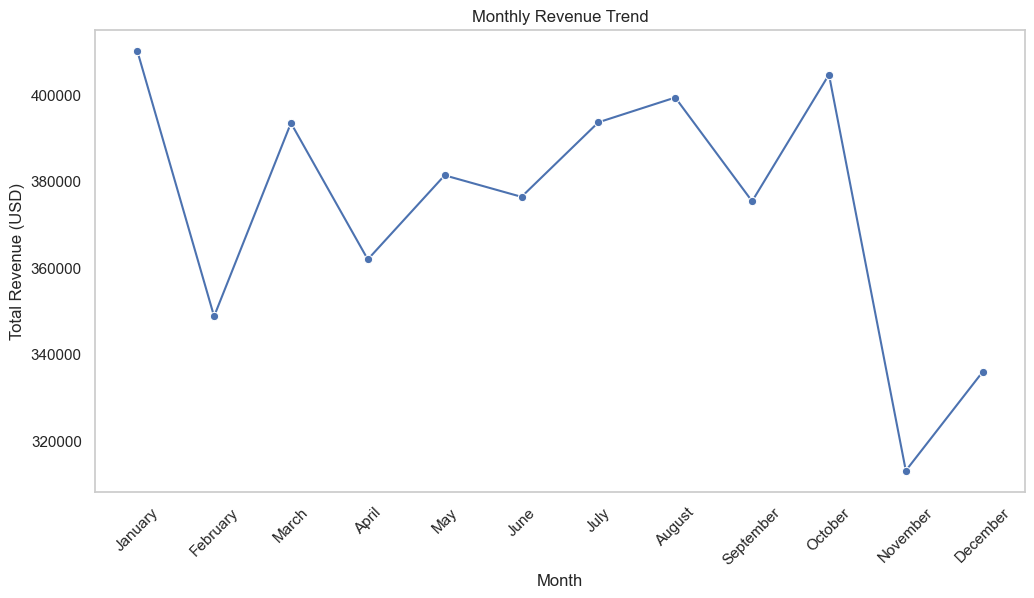

In [10]:
revenue_by_month = orders.groupby('month')['total_usd'].sum().reindex([
    'January', 'February', 'March', 'April', 'May', 'June',
    'July', 'August', 'September', 'October', 'November', 'December'
])



plt.figure(figsize=(12,6))
sns.lineplot(x=revenue_by_month.index, y=revenue_by_month.values, marker='o')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45)
plt.grid()
plt.show()


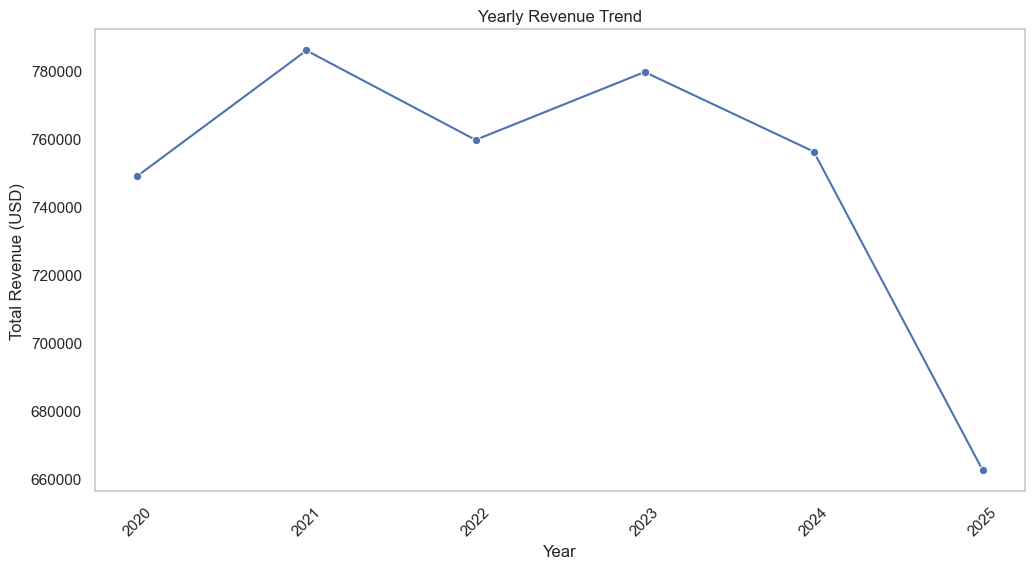

In [33]:
revenue_by_year = orders.groupby('year')['total_usd'].sum()


plt.figure(figsize=(12,6))
sns.lineplot(x=revenue_by_year.index, y=revenue_by_year.values, marker='o')
plt.title('Yearly Revenue Trend')
plt.xlabel('Year')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45)
plt.grid()
plt.show()

Revenue trend is stable long-term but volatile month-to-month.

## Marketing Channel Performance

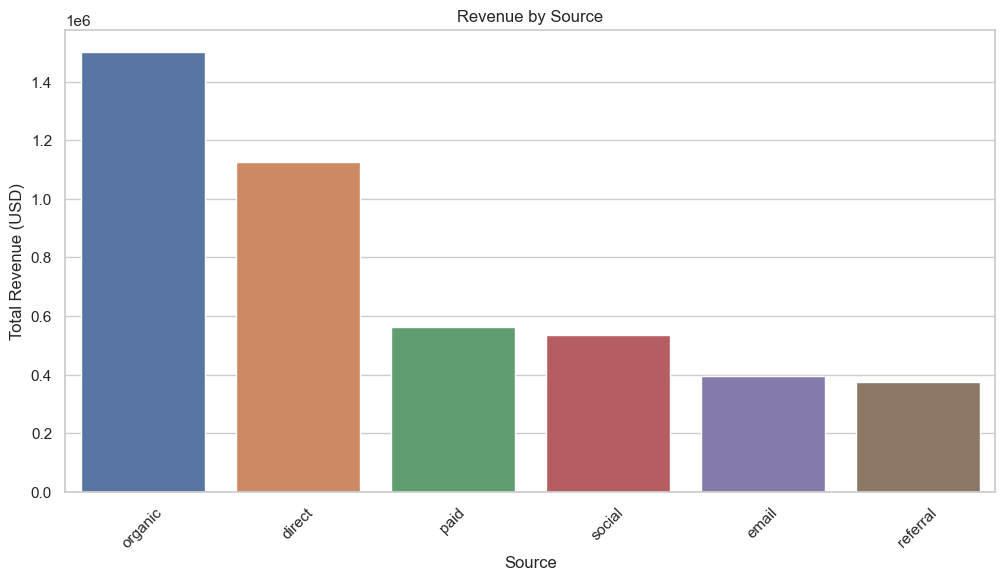

source
organic     1501632.60
direct      1124754.89
paid         561639.48
social       536240.79
email        395243.16
referral     373706.55
Name: total_usd, dtype: float64

In [11]:

channel_revenue = (
    orders.groupby('source')['total_usd']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,6))
sns.barplot(x=channel_revenue.index, y=channel_revenue.values,hue=channel_revenue.index)
plt.title('Revenue by Source')
plt.xlabel('Source')
plt.ylabel('Total Revenue (USD)')
plt.xticks(rotation=45)
plt.show()


channel_revenue

Organic and direct channels are top scale contributors.

## Device Performance

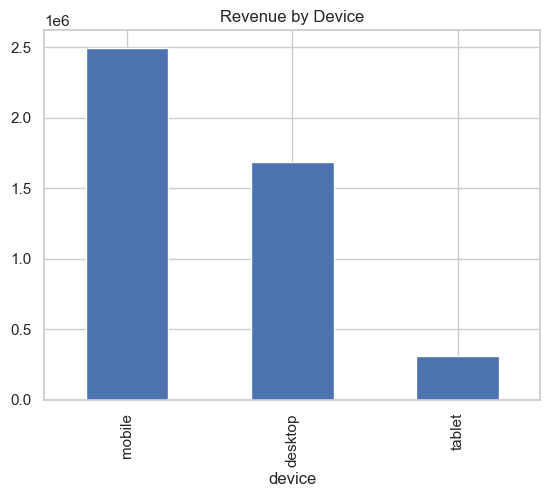

In [12]:

device_revenue = (
    orders.groupby('device')['total_usd']
    .sum()
    .sort_values(ascending=False)
)

device_revenue.plot(kind='bar')
plt.title('Revenue by Device')
plt.show()


## Product Performance Analysis

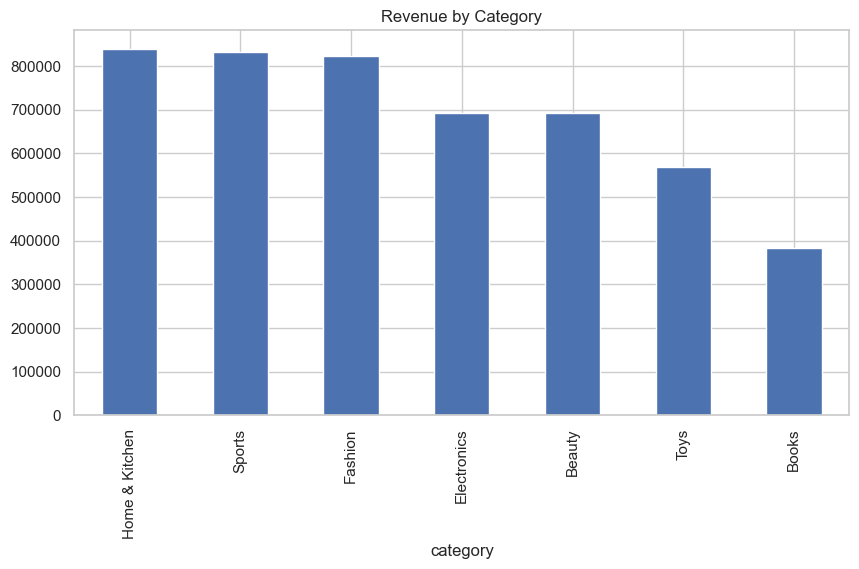

category
Home & Kitchen    840379.82
Sports            831697.80
Fashion           824307.04
Electronics       692383.39
Beauty            691692.89
Toys              568734.90
Books             383155.39
Name: line_total_usd, dtype: float64

In [13]:

product_sales = (
    order_items
    .merge(products,on='product_id')
)

category_revenue = (
    product_sales.groupby('category')['line_total_usd']
    .sum()
    .sort_values(ascending=False)
)

category_revenue.plot(kind='bar', figsize=(10,5))
plt.title('Revenue by Category')
plt.show()

category_revenue


## Product Profitability

In [14]:

product_sales['cost_total'] = (
    product_sales['cost_usd']
    * product_sales['quantity']
)

product_sales['profit'] = (
    product_sales['line_total_usd']
    - product_sales['cost_total']
)

profit_by_category = (
    product_sales.groupby('category')['profit']
    .sum()
    .sort_values(ascending=False)
)

profit_by_category


category
Home & Kitchen    300476.77
Sports            292879.03
Fashion           287245.82
Electronics       257257.86
Beauty            245431.73
Toys              193812.33
Books             135060.08
Name: profit, dtype: float64

## Customer Analytics

In [15]:

customer_revenue = (
    orders.groupby('customer_id')['total_usd']
    .sum()
)

customer_revenue.describe()


count    16268.000000
mean       276.199746
std        265.202586
min          2.800000
25%         91.547500
50%        199.775000
75%        376.512500
max       3026.420000
Name: total_usd, dtype: float64

## RFM Segmentation
- Recency: The time difference between the snapshot_date and the customer's last order date. Lower is better.

- Frequency: The count of unique order_id entries per customer. Higher is better.

- Monetary: The sum of total_usd spent per customer. Higher is better.

In [16]:

snapshot_date = orders['order_time'].max() + pd.Timedelta(days=1)

#metric calculation
rfm = orders.groupby('customer_id').agg({
    'order_time': lambda x:(snapshot_date - x.max()).days,
    'order_id':'nunique',
    'total_usd':'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

#Normalization and scoring
rfm['R'] = pd.qcut(rfm['Recency'],4,labels=[4,3,2,1])
rfm['F'] = pd.qcut(rfm['Frequency'].rank(method='first'),4,labels=[1,2,3,4])
rfm['M'] = pd.qcut(rfm['Monetary'],4,labels=[1,2,3,4])

#Scoring
rfm['RFM_Score'] = (
    rfm['R'].astype(str)
    + rfm['F'].astype(str)
    + rfm['M'].astype(str)
)

rfm



,Recency,Frequency,Monetary,R,F,M,RFM_Score
customer_id,,,,,,,
1,129,2,115.39,4,2,2,422
2,303,2,68.52,3,2,1,321
3,1946,1,66.72,1,1,1,111
4,823,2,279.86,2,2,3,223
5,275,3,271.29,4,3,3,433
...,...,...,...,...,...,...,...
19993,1221,3,670.67,1,4,4,144
19994,1760,1,263.30,1,2,3,123
19996,1309,1,65.53,1,2,1,121


## Funnel Analysis

In [17]:
session_events = events.merge(
    sessions[['session_id','customer_id','device','source','country']],
    on='session_id',
    how='left'
)

session_events.head()


,event_id,session_id,timestamp,event_type,product_id,qty,cart_size,payment,discount_pct,amount_usd,customer_id,device,source,country
0,1,1,2021-12-27 00:08:36,page_view,93.0,NaN,NaN,NaN,NaN,NaN,12360,mobile,email,DE
1,2,1,2021-12-27 00:16:36,page_view,1005.0,NaN,NaN,NaN,NaN,NaN,12360,mobile,email,DE
2,3,1,2021-12-27 00:18:01,add_to_cart,1005.0,1.0,NaN,NaN,NaN,NaN,12360,mobile,email,DE
3,4,1,2021-12-27 00:45:36,page_view,918.0,NaN,NaN,NaN,NaN,NaN,12360,mobile,email,DE
4,5,1,2021-12-27 01:03:36,page_view,946.0,NaN,NaN,NaN,NaN,NaN,12360,mobile,email,DE


### Event Taxonomy

In [18]:

event_summary = events['event_type'].value_counts().reset_index()
event_summary


,event_type,count
0,page_view,539343
1,add_to_cart,143126
2,checkout,44909
3,purchase,33580


### Source Quality Funnel

In [31]:
session_source = sessions.groupby('source')['session_id'].nunique().reset_index(name='sessions')

order_source = orders.groupby('source').agg(
    orders=('order_id','nunique'),
    revenue=('total_usd','sum')
).reset_index()

source_funnel = session_source.merge(order_source,on='source',how='left')
source_funnel['conversion_rate'] = source_funnel['orders']/source_funnel['sessions']*100

source_funnel.sort_values('conversion_rate',ascending=False)


,source,sessions,orders,revenue,conversion_rate
4,referral,9560,2724,373706.55,28.493724
3,paid,14465,4121,561639.48,28.489457
0,direct,29861,8387,1124754.89,28.086802
5,social,14389,4024,536240.79,27.965807
1,email,10949,3056,395243.16,27.911225
2,organic,40776,11268,1501632.60,27.633902


Organic and direct channels are top scale contributors.

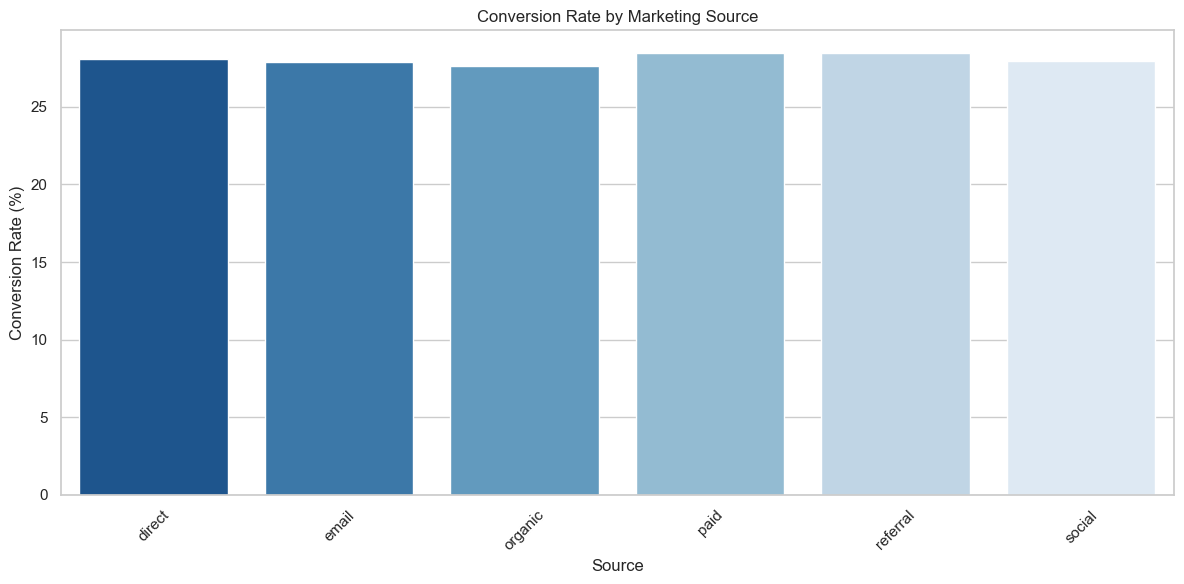

In [20]:


plt.figure(figsize=(12, 6))
sns.barplot(
    x=source_funnel['source'],
    y=source_funnel['conversion_rate'],
    palette='Blues_r',
    hue=source_funnel['source'],
 )
plt.title('Conversion Rate by Marketing Source')
plt.xlabel('Source')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



### Device Funnel

In [21]:

device_sessions = sessions.groupby('device')['session_id'].nunique().reset_index(name='sessions')

device_orders = orders.groupby('device').agg(
    orders=('order_id','count'),
    revenue=('total_usd','sum')
).reset_index()

device_funnel = device_sessions.merge(device_orders,on='device')
device_funnel['conversion_rate'] = device_funnel['orders']/device_funnel['sessions']*100

device_funnel


,device,sessions,orders,revenue,conversion_rate
0,desktop,45547,12750,1683869.59,27.993062
1,mobile,65942,18469,2496380.33,28.007946
2,tablet,8511,2361,312967.55,27.740571


Mobile drives the largest order and revenue share.

### Country Funnel

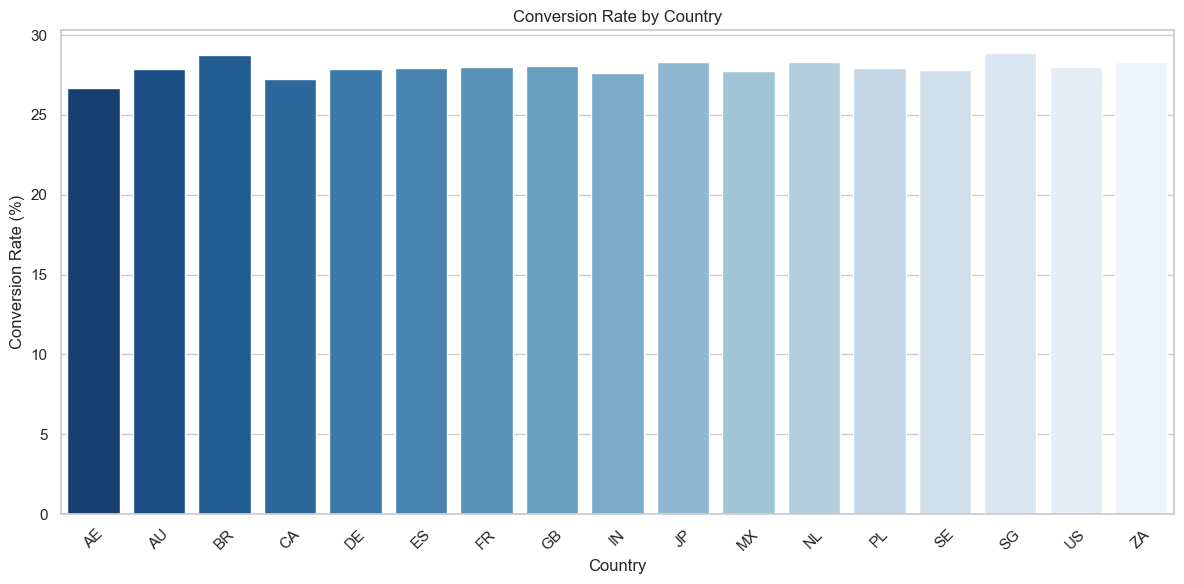

In [22]:

country_sessions = sessions.groupby('country')['session_id'].nunique().reset_index(name='sessions')

country_orders = orders.groupby('country').agg(
    orders=('order_id','count'),
    revenue=('total_usd','sum')
).reset_index()

country_funnel = country_sessions.merge(country_orders,on='country')
country_funnel['conversion_rate']=country_funnel['orders']/country_funnel['sessions']*100

country_funnel.sort_values('revenue',ascending=False).head(20)

plt.figure(figsize=(12,6))
sns.barplot(
    x=country_funnel['country'],
    y=country_funnel['conversion_rate'],
    palette='Blues_r',
    hue=country_funnel['country']
)
plt.title('Conversion Rate by Country')
plt.xlabel('Country')
plt.ylabel('Conversion Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Revenue Leakage Estimation

In [23]:

total_sessions = sessions['session_id'].nunique()
total_orders = orders['order_id'].nunique()

avg_order_value = orders['total_usd'].mean()

lost_visitors = total_sessions-total_orders

potential_revenue = lost_visitors*avg_order_value

pd.DataFrame({
    'sessions':[total_sessions],
    'orders':[total_orders],
    'lost_visitors':[lost_visitors],
    'avg_order_value':[avg_order_value],
    'potential_revenue':[potential_revenue]
})


,sessions,orders,lost_visitors,avg_order_value,potential_revenue
0,120000,33580,86420,133.806357,1.156355e+07


## Pareto Analysis

In [24]:

product_rev = (
    product_sales.groupby('product_id')['line_total_usd']
    .sum()
    .sort_values(ascending=False)
)

pareto = product_rev.reset_index()
pareto['cum_pct'] = (
    pareto['line_total_usd'].cumsum()
    / pareto['line_total_usd'].sum()
)

pareto.head()


,product_id,line_total_usd,cum_pct
0,104,9860.40,0.002040
1,120,9286.88,0.003962
2,51,9212.80,0.005869
3,9,8962.74,0.007724
4,801,8874.24,0.009560


## Review Analysis

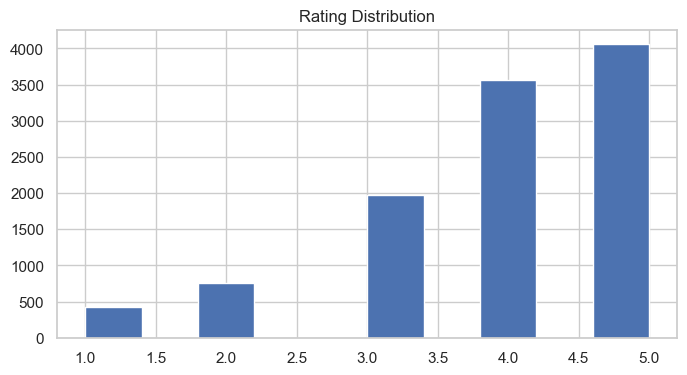

count    10780.000000
mean         3.934323
std          1.090722
min          1.000000
25%          3.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: rating, dtype: float64

In [25]:

rating_summary = reviews['rating'].describe()

plt.figure(figsize=(8,4))
reviews['rating'].hist()
plt.title('Rating Distribution')
plt.show()

rating_summary


## Geographic Analysis

In [26]:

country_revenue = (
    orders.groupby('country')['total_usd']
    .sum()
    .sort_values(ascending=False)
)

country_revenue.head(10)


country
US    823420.19
GB    355863.06
IN    345574.03
BR    323063.65
DE    297669.52
FR    297325.36
MX    275336.06
AU    242263.71
CA    220944.75
ES    213972.24
Name: total_usd, dtype: float64

## Correlation Analysis

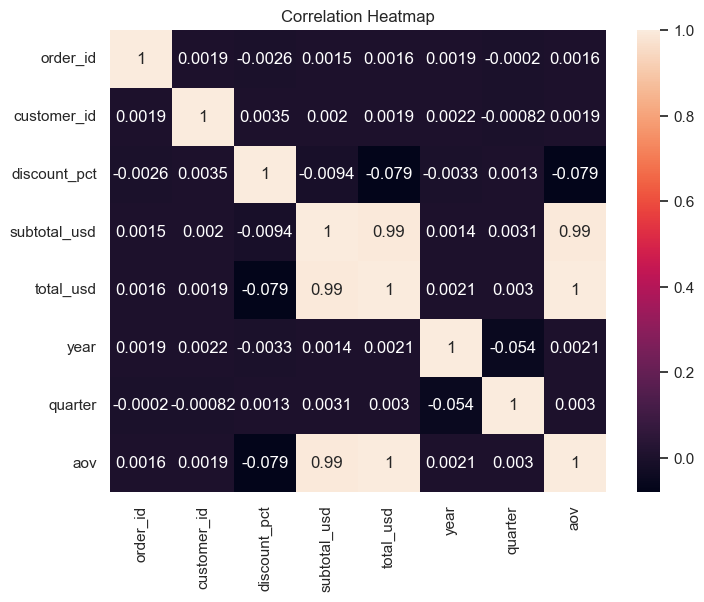

In [27]:

numeric_cols = orders.select_dtypes(include=np.number)

corr = numeric_cols.corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title('Correlation Heatmap')
plt.show()



# Key Insights
Major drop-off appears between add-to-cart and checkout.
Mobile drives the largest order and revenue share.
Organic and direct channels are top scale contributors.
VIP segment contributes a disproportionate share of total revenue.
Category leadership is distributed, reducing single-category dependency risk.
Product concentration is moderate rather than extreme.
Repeat purchase behavior is strong and valuable.
Gross margin profile remains healthy.
Revenue trend is stable long-term but volatile month-to-month.
Review sentiment is broadly positive and can be leveraged for conversion uplift.


# Recommendations
- Prioritize cart-to-checkout UX optimization to reduce abandonment.
- Scale high-quality traffic sources (organic/referral mix).
- Build VIP retention programs with proactive churn prevention.
- Use category scorecards to optimize promotional and inventory strategy.
- Operationalize review-driven merchandising on product and landing pages.


# Conclusion
The business demonstrates strong revenue scale, healthy margin potential, and positive customer sentiment. The largest near-term growth opportunity is improving checkout initiation from cart, while long-term performance can be strengthened through segment-led retention, channel quality expansion, and category-level optimization.

